In [1]:
# Standard libraries
import os
import re
import json
import glob
import warnings
warnings.filterwarnings('ignore') 

# Data processing
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
# Force non-interactive backend to prevent kernel/async errors
matplotlib.use('Agg') 
from IPython.display import display, Image

# Machine learning
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, 
    roc_auc_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)

# XGBoost and Saving
import xgboost as xgb
import joblib

print("All libraries imported!")
print(f"XGBoost version: {xgb.__version__}")

All libraries imported!
XGBoost version: 3.2.0


In [2]:
# Use forward slashes — avoids \R escape error on Windows
BASE          = "D:/R26-IT-096/R26-IT-096/server/microservice-3/python_ml"
DATASETS_PATH = f"{BASE}/data/raw"
TEAMS_PATH    = f"{BASE}/data/raw/Teams"

# New folders you added
PLAYER_RECORDS_PATH = "D:/datasets/player records"
GROUNDS_PATH        = "D:/datasets/grounds international"

PATHS = {
    # Existing datasets
    "squads"             : f"{DATASETS_PATH}/squads.csv",
    "most_runs_t20"      : f"{DATASETS_PATH}/most_runst20_2025.csv",
    "most_runs_odi"      : f"{DATASETS_PATH}/most_runsODI_2025.csv",
    "most_runs_test"     : f"{DATASETS_PATH}/most_runsTest_2025.csv",
    "most_wickets_t20"   : f"{DATASETS_PATH}/most_wicketst20_2025.csv",
    "most_wickets_odi"   : f"{DATASETS_PATH}/most_wicketsODI_2025.csv",
    "most_wickets_test"  : f"{DATASETS_PATH}/most_wicketsTest_2025.csv",
    "best_avg_t20"       : f"{DATASETS_PATH}/best_averageT20_2025.csv",
    "best_avg_odi"       : f"{DATASETS_PATH}/best_averageODI_2025.csv",
    "best_avg_test"      : f"{DATASETS_PATH}/best_average_Test2025.csv",
    "best_economy_odi"   : f"{DATASETS_PATH}/best_economyODI_2025.csv",
    "best_economy_test"  : f"{DATASETS_PATH}/best_economyrateTest_2025.csv",
    "venues_intl"        : f"{DATASETS_PATH}/venues_international.csv",
    "matches"            : f"{DATASETS_PATH}/matches.csv",
    "batting_stats"      : f"{DATASETS_PATH}/batting_stats.csv",
    "bowling_stats"      : f"{DATASETS_PATH}/bowling_stats.csv",
    "key_scorecards"     : f"{DATASETS_PATH}/key_scorecards.csv",
    "awards"             : f"{DATASETS_PATH}/awards.csv",
    "tournament_summary" : f"{DATASETS_PATH}/tournament_summary.csv",

    # Ground datasets
    "allgrounds"         : f"{GROUNDS_PATH}/allgrounds.csv",
    "odi_home_away"      : f"{GROUNDS_PATH}/odi_home_away_win.csv",
    "odi_rpo"            : f"{GROUNDS_PATH}/odi_runsscoredperover_allgrounds.csv",
    "odi_rpw"            : f"{GROUNDS_PATH}/odi_runsscoredperwicket_allgrounds.csv",
    "t20_rpo"            : f"{GROUNDS_PATH}/t20_runsscoredperover_allgrounds.csv",
    "t20_rpw"            : f"{GROUNDS_PATH}/t20_runsscoredperwicket_allgrounds.csv",
    "test_home_away"     : f"{GROUNDS_PATH}/test_home_away_win.csv",
    "test_rpo"           : f"{GROUNDS_PATH}/test_runsscoredperover_allgrounds.csv",
    "test_rpw"           : f"{GROUNDS_PATH}/test_runsscoredperwicket_allgrounds.csv",
    "test_high_stand"    : f"{GROUNDS_PATH}/test_highest_average_stands.csv",
    "test_low_stand"     : f"{GROUNDS_PATH}/test_lowest_average_opening_stand.csv",
}

print("=" * 60)
print("FILE CHECK")
print("=" * 60)
for name, path in PATHS.items():
    s = "FOUND  " if os.path.exists(path) else "MISSING"
    print(f"  [{s}] {name:<25} {os.path.basename(path)}")

print(f"\nTeams folder   : {'FOUND' if os.path.exists(TEAMS_PATH) else 'MISSING'}")
print(f"Player Records : {'FOUND' if os.path.exists(PLAYER_RECORDS_PATH) else 'MISSING'}")
print(f"Grounds folder : {'FOUND' if os.path.exists(GROUNDS_PATH) else 'MISSING'}")

FILE CHECK
  [FOUND  ] squads                    squads.csv
  [FOUND  ] most_runs_t20             most_runst20_2025.csv
  [FOUND  ] most_runs_odi             most_runsODI_2025.csv
  [FOUND  ] most_runs_test            most_runsTest_2025.csv
  [FOUND  ] most_wickets_t20          most_wicketst20_2025.csv
  [FOUND  ] most_wickets_odi          most_wicketsODI_2025.csv
  [FOUND  ] most_wickets_test         most_wicketsTest_2025.csv
  [FOUND  ] best_avg_t20              best_averageT20_2025.csv
  [FOUND  ] best_avg_odi              best_averageODI_2025.csv
  [FOUND  ] best_avg_test             best_average_Test2025.csv
  [FOUND  ] best_economy_odi          best_economyODI_2025.csv
  [FOUND  ] best_economy_test         best_economyrateTest_2025.csv
  [FOUND  ] venues_intl               venues_international.csv
  [FOUND  ] matches                   matches.csv
  [FOUND  ] batting_stats             batting_stats.csv
  [FOUND  ] bowling_stats             bowling_stats.csv
  [FOUND  ] key_scoreca

In [3]:
def safe_load(path, name):
    """Load CSV trying multiple encodings."""
    for enc in ['utf-8', 'latin-1', 'cp1252', 'iso-8859-1']:
        try:
            df = pd.read_csv(path, encoding=enc)
            print(f"  LOADED  {name:<30} shape={str(df.shape):<14} "
                  f"cols={df.columns.tolist()[:5]}")
            return df
        except UnicodeDecodeError:
            continue
        except FileNotFoundError:
            print(f"  MISSING {name:<30} not found")
            return pd.DataFrame()
        except Exception as e:
            print(f"  ERROR   {name:<30} {e}")
            return pd.DataFrame()
    print(f"  FAILED  {name:<30} all encodings failed")
    return pd.DataFrame()

print("=" * 60)
print("LOADING ALL DATASETS")
print("=" * 60)

squads_df         = safe_load(PATHS["squads"],            "squads")
runs_t20_df       = safe_load(PATHS["most_runs_t20"],     "most_runs_t20")
runs_odi_df       = safe_load(PATHS["most_runs_odi"],     "most_runs_odi")
runs_test_df      = safe_load(PATHS["most_runs_test"],    "most_runs_test")
wkts_t20_df       = safe_load(PATHS["most_wickets_t20"],  "most_wickets_t20")
wkts_odi_df       = safe_load(PATHS["most_wickets_odi"],  "most_wickets_odi")
wkts_test_df      = safe_load(PATHS["most_wickets_test"], "most_wickets_test")
avg_t20_df        = safe_load(PATHS["best_avg_t20"],      "best_avg_t20")
avg_odi_df        = safe_load(PATHS["best_avg_odi"],      "best_avg_odi")
avg_test_df       = safe_load(PATHS["best_avg_test"],     "best_avg_test")
econ_odi_df       = safe_load(PATHS["best_economy_odi"],  "best_economy_odi")
econ_test_df      = safe_load(PATHS["best_economy_test"], "best_economy_test")
venues_df         = safe_load(PATHS["venues_intl"],       "venues_international")
matches_df        = safe_load(PATHS["matches"],           "matches")
batting_stats_df  = safe_load(PATHS["batting_stats"],     "batting_stats")
bowling_stats_df  = safe_load(PATHS["bowling_stats"],     "bowling_stats")
key_scorecards_df = safe_load(PATHS["key_scorecards"],    "key_scorecards")
awards_df         = safe_load(PATHS["awards"],            "awards")
tournament_df     = safe_load(PATHS["tournament_summary"],"tournament_summary")

print("\n--- GROUND DATASETS ---")
allgrounds_df     = safe_load(PATHS["allgrounds"],        "allgrounds")
odi_home_away_df  = safe_load(PATHS["odi_home_away"],     "odi_home_away")
odi_rpo_df        = safe_load(PATHS["odi_rpo"],           "odi_rpo")
odi_rpw_df        = safe_load(PATHS["odi_rpw"],           "odi_rpw")
t20_rpo_df        = safe_load(PATHS["t20_rpo"],           "t20_rpo")
t20_rpw_df        = safe_load(PATHS["t20_rpw"],           "t20_rpw")
test_home_away_df = safe_load(PATHS["test_home_away"],    "test_home_away")
test_rpo_df       = safe_load(PATHS["test_rpo"],          "test_rpo")
test_rpw_df       = safe_load(PATHS["test_rpw"],          "test_rpw")
test_high_stand_df= safe_load(PATHS["test_high_stand"],   "test_high_stand")
test_low_stand_df = safe_load(PATHS["test_low_stand"],    "test_low_stand")

# Print exact column names for allgrounds
# This helps us confirm which column holds T20, ODI, Test counts
print("\nAllgrounds exact columns:", allgrounds_df.columns.tolist())
print(allgrounds_df.head(3))

LOADING ALL DATASETS
  LOADED  squads                         shape=(300, 4)       cols=['team', 'player_name', 'role', 'designation']
  LOADED  most_runs_t20                  shape=(150, 15)      cols=['Player', 'Span', 'Mat', 'Inns', 'NO']
  LOADED  most_runs_odi                  shape=(150, 15)      cols=['Player', 'Span', 'Mat', 'Inns', 'NO']
  LOADED  most_runs_test                 shape=(150, 15)      cols=['Player', 'Span', 'Mat', 'Inns', 'NO']
  LOADED  most_wickets_t20               shape=(100, 15)      cols=['Player', 'Span', 'Mat', 'Inns', 'Balls']
  LOADED  most_wickets_odi               shape=(100, 15)      cols=['Player', 'Span', 'Mat', 'Inns', 'Balls']
  LOADED  most_wickets_test              shape=(100, 16)      cols=['Player', 'Span', 'Mat', 'Inns', 'Balls']
  LOADED  best_avg_t20                   shape=(100, 16)      cols=['Player', 'Span', 'Mat', 'Inns', 'Balls']
  LOADED  best_avg_odi                   shape=(419, 12)      cols=['Player', 'Span', 'Mat', 'Inns', 'NO

In [4]:
def load_player_records(player_records_path, fmt):
    """
    Load player career records.
    Files named like: t20_ausrecords.csv, odi_indrecords.csv
    Columns: Name, Known As, Career, Matches, Inns, Runs,
             100s, HS, Bat Avg, Wkts, 5W, Bowl Avg, E/R
    """
    records = []

    if not os.path.exists(player_records_path):
        print(f"Player records path not found: {player_records_path}")
        return pd.DataFrame()

    for team_folder in sorted(os.listdir(player_records_path)):
        fp = os.path.join(player_records_path, team_folder)
        if not os.path.isdir(fp):
            continue

        # Extract clean team name from folder name
        team_name = team_folder.replace("_players", "")

        for f in os.listdir(fp):
            if not f.endswith(".csv"):
                continue
            # Match format: t20_, odi_, test_
            if not f.lower().startswith(fmt.lower() + "_"):
                continue

            file_path = os.path.join(fp, f)
            for enc in ['utf-8', 'latin-1', 'cp1252']:
                try:
                    df = pd.read_csv(file_path, encoding=enc)
                    df["team"]   = team_name
                    df["format"] = fmt.upper()
                    records.append(df)
                    print(f"  LOADED  {team_name:<20} {f:<30} {len(df)} players")
                    break
                except UnicodeDecodeError:
                    continue
                except Exception as e:
                    print(f"  ERROR   {team_name}/{f}: {e}")
                    break

    if records:
        combined = pd.concat(records, ignore_index=True)
        print(f"\n  {fmt.upper()} player records: {len(combined)} from {len(records)} teams")
        return combined
    return pd.DataFrame()

print("=" * 60)
print("LOADING PLAYER RECORDS")
print("=" * 60)

print("\n--- T20 ---")
pr_t20  = load_player_records(PLAYER_RECORDS_PATH, "t20")
print("\n--- ODI ---")
pr_odi  = load_player_records(PLAYER_RECORDS_PATH, "odi")
print("\n--- Test ---")
pr_test = load_player_records(PLAYER_RECORDS_PATH, "test")

if not pr_t20.empty:
    print(f"\nPlayer records T20 columns: {pr_t20.columns.tolist()}")
    print(pr_t20.head(3))

LOADING PLAYER RECORDS

--- T20 ---
  LOADED  Afghanistan          t20_afgrecords.csv             38 players
  LOADED  Australia            t20_ausrecords.csv             37 players
  LOADED  Bangladesh           t20_banrecords.csv             38 players
  LOADED  England              t20_engrecords.csv             31 players
  LOADED  India                t20_indrecords.csv             38 players
  LOADED  Ireland              t20_irerecords.csv             21 players
  LOADED  New Zealand          t20_nzrecords.csv              41 players
  LOADED  Pakistan             t20_pakrecords.csv             49 players
  LOADED  South Africa         t20_sarecords.csv              43 players
  LOADED  Sri Lanka            t20_slrecords.csv              40 players
  LOADED  West Indies          t20_wirecords.csv              38 players
  LOADED  Zimbabwe             t20_zimrecords.csv             32 players

  T20 player records: 446 from 12 teams

--- ODI ---
  LOADED  Afghanistan          odi

In [5]:
def load_team_format(teams_path, fmt):
    """Load team roster CSVs and prevent duplicate player rows immediately."""
    records = []
    if not os.path.exists(teams_path):
        print(f"Teams path not found: {teams_path}")
        return pd.DataFrame()

    for team_folder in sorted(os.listdir(teams_path)):
        fp = os.path.join(teams_path, team_folder)
        if not os.path.isdir(fp): continue
        for f in os.listdir(fp):
            if not f.endswith(".csv") or not f.upper().startswith(fmt.upper()):
                continue
            
            file_path = os.path.join(fp, f)
            for enc in ['utf-8', 'latin-1', 'cp1252']:
                try:
                    df = pd.read_csv(file_path, encoding=enc)
                    df["team"]   = team_folder
                    df["format"] = fmt
                    records.append(df)
                    print(f"  LOADED  {team_folder:<16} {f:<22} {len(df)} players")
                    break
                except Exception: continue

    if records:
        combined = pd.concat(records, ignore_index=True)
        # Check for column variations of "Player Name"
        name_col = next((c for c in combined.columns if c.lower() in ["player", "name"]), None)
        if name_col:
            combined = combined.drop_duplicates(subset=[name_col, "team"], keep="first")
            
        print(f"\n  {fmt} TOTAL: {len(combined)} unique players loaded")
        return combined.reset_index(drop=True)
    return pd.DataFrame()

# --- THE FIX: CALLING THE FUNCTIONS ---
print("=" * 60)
print("LOADING TEAM ROSTERS")
print("=" * 60)
t20_teams  = load_team_format(TEAMS_PATH, "T20")
odi_teams  = load_team_format(TEAMS_PATH, "ODI")
test_teams = load_team_format(TEAMS_PATH, "TEST")

LOADING TEAM ROSTERS
  LOADED  Afghanistan      T20_afg.csv            15 players
  LOADED  Australia        T20_aus.csv            15 players
  LOADED  Bangladesh       T20_ban.csv            15 players
  LOADED  England          T20_eng.csv            16 players
  LOADED  India            T20_ind.csv            16 players
  LOADED  Ireland          T20_ire.csv            15 players
  LOADED  New Zealand      T20_nz.csv             16 players
  LOADED  Pakistan         T20_pak.csv            17 players
  LOADED  South Africa     T20_sa.csv             15 players
  LOADED  Sri Lanka        T20_sl.csv             15 players
  LOADED  West Indies      T20_wi.csv             15 players
  LOADED  Zimbabwe         T20_zim.csv            15 players

  T20 TOTAL: 185 unique players loaded
  LOADED  Afghanistan      ODI_afg.csv            15 players
  LOADED  Australia        ODI_aus.csv            15 players
  LOADED  Bangladesh       ODI_ban.csv            15 players
  LOADED  England       

In [6]:
def load_team_format(teams_path, fmt):
    """Load team roster CSVs and prevent duplicate player rows immediately."""
    records = []
    if not os.path.exists(teams_path):
        print(f"Teams path not found: {teams_path}")
        return pd.DataFrame()

    for team_folder in sorted(os.listdir(teams_path)):
        fp = os.path.join(teams_path, team_folder)
        if not os.path.isdir(fp):
            continue
        for f in os.listdir(fp):
            if not f.endswith(".csv") or not f.upper().startswith(fmt.upper()):
                continue
            
            file_path = os.path.join(fp, f)
            for enc in ['utf-8', 'latin-1', 'cp1252']:
                try:
                    df = pd.read_csv(file_path, encoding=enc)
                    df["team"]   = team_folder
                    df["format"] = fmt
                    records.append(df)
                    print(f"  LOADED  {team_folder:<16} {f:<22} {len(df)} players")
                    break
                except Exception:
                    continue

    if records:
        combined = pd.concat(records, ignore_index=True)
        # Fix: Remove duplicate players within the same format/team load
        if "Player" in combined.columns:
            combined = combined.drop_duplicates(subset=["Player", "team"], keep="first")
        elif "Name" in combined.columns:
            combined = combined.drop_duplicates(subset=["Name", "team"], keep="first")
            
        print(f"\n  {fmt} TOTAL: {len(combined)} unique players loaded")
        return combined.reset_index(drop=True)
    return pd.DataFrame()

In [7]:
def standardize_columns(df):
    """
    Rename all column name variations to consistent names.
    Fixes the issue of duplicate standard names (e.g., mapping both 'Avg' and 'Ave' to 'bat_avg').
    """
    if df.empty:
        return df

    # Create a fresh copy to avoid SettingWithCopy warnings
    df = df.copy()
    
    # 1. First Pass: Clean existing column names for hidden characters/spaces
    df.columns = [str(c).strip() for c in df.columns]

    col_map = {}
    seen_targets = set() # CRITICAL: Prevents creating duplicate column names

    # Priority mapping logic
    for col in df.columns:
        c_raw = col
        cl = col.lower()

        target = None

        # Player name
        if cl in ["player", "name"]: target = "player_name"
        elif cl in ["known as", "known_as"]: target = "known_as"
        elif cl in ["role", "position"]: target = "role"
        elif cl in ["career", "span"]: target = "career_span"

        # Batting stats
        elif cl == "runs": target = "runs"
        elif cl in ["bat avg", "bat_avg", "batting avg", "ave", "avg", "average", "batting average"]:
            target = "bat_avg"
        elif cl in ["sr", "strike rate", "strike_rate", "batting sr"]:
            target = "strike_rate"
        elif cl in ["hs", "highest", "highest score"]: target = "highest_score"
        elif cl in ["100s", "100", "centuries"]: target = "centuries"
        elif cl in ["mat", "matches", "matches played"]: target = "matches_played"
        elif cl in ["inns", "innings"]: target = "innings"
        elif cl in ["bf", "balls_faced", "balls faced"]: target = "balls_faced"

        # Bowling stats
        elif cl in ["wickets", "wkts"]: target = "wickets"
        elif cl in ["bowl avg", "bowl_avg", "bowling avg", "bowling average"]:
            target = "bowl_avg"
        elif cl in ["e/r", "er", "econ", "economy", "economy rate"]:
            target = "economy"
        elif cl in ["5w", "five wickets", "five_wickets"]: target = "five_wickets"
        elif cl == "bbi": target = "bbi"

        # Ground columns
        elif cl == "ground": target = "ground_name"
        elif cl in ["rpo", "runs per over"]: target = "rpo"
        elif cl in ["rpw", "runs per wicket"]: target = "rpw"
        elif "home win" in cl or cl == "home_win": target = "home_win_pct"
        elif "away win" in cl or cl == "away_win": target = "away_win_pct"

        # ONLY map if we haven't already used this target name in this dataframe
        if target and target not in seen_targets:
            col_map[c_raw] = target
            seen_targets.add(target)

    # 2. Rename columns
    df = df.rename(columns=col_map)
    
    # 3. Final Safety: Force unique columns by dropping any unintended duplicates
    df = df.loc[:, ~df.columns.duplicated(keep='first')].copy()
    
    return df

# --- Apply to all dataframes ---
t20_teams    = standardize_columns(t20_teams)
odi_teams    = standardize_columns(odi_teams)
test_teams   = standardize_columns(test_teams)
runs_t20_df  = standardize_columns(runs_t20_df)
runs_odi_df  = standardize_columns(runs_odi_df)
runs_test_df = standardize_columns(runs_test_df)
wkts_t20_df  = standardize_columns(wkts_t20_df)
wkts_odi_df  = standardize_columns(wkts_odi_df)
wkts_test_df = standardize_columns(wkts_test_df)
avg_t20_df   = standardize_columns(avg_t20_df)
avg_odi_df   = standardize_columns(avg_odi_df)
avg_test_df  = standardize_columns(avg_test_df)
econ_odi_df  = standardize_columns(econ_odi_df)
econ_test_df = standardize_columns(econ_test_df)
squads_df    = standardize_columns(squads_df)
pr_t20        = standardize_columns(pr_t20)
pr_odi        = standardize_columns(pr_odi)
pr_test       = standardize_columns(pr_test)

allgrounds_df     = standardize_columns(allgrounds_df)
odi_home_away_df  = standardize_columns(odi_home_away_df)
odi_rpo_df        = standardize_columns(odi_rpo_df)
odi_rpw_df        = standardize_columns(odi_rpw_df)
t20_rpo_df        = standardize_columns(t20_rpo_df)
t20_rpw_df        = standardize_columns(t20_rpw_df)
test_home_away_df = standardize_columns(test_home_away_df)
test_rpo_df       = standardize_columns(test_rpo_df)
test_rpw_df       = standardize_columns(test_rpw_df)

print("Standardization done with Duplicate Protection!")

Standardization done with Duplicate Protection!


In [8]:
def extract_name(full_name):
    """Normalize player name for cross-dataset matching."""
    if pd.isna(full_name):
        return ""
    # Removes country codes like (IN), (AUS)
    name = re.sub(r'\(.*?\)', '', str(full_name)).strip()
    # Remove extra spaces
    name = re.sub(r'\s+', ' ', name)
    return name.lower()

def find_name_col(df):
    """Find which column holds player name in a dataframe."""
    for col in ["player_name", "known_as", "name"]:
        if col in df.columns:
            return col
    return None

def merge_stat(master, stat_df, stat_cols, suffix=""):
    """Merge stat dataframe into master using player name key with index safety."""
    if stat_df.empty:
        return master

    name_col = find_name_col(stat_df)
    if name_col is None:
        print(f"  WARNING: No name column found in stat df")
        return master

    stat_df = stat_df.copy()
    stat_df["name_key"] = stat_df[name_col].apply(extract_name)

    # Filter for requested columns that actually exist
    existing_cols = [c for c in stat_cols if c in stat_df.columns]
    keep = ["name_key"] + existing_cols
    
    if len(keep) == 1: # Only name_key exists
        return master

    # CRITICAL: Remove duplicates before merging to prevent row multiplication
    stat_df = stat_df[keep].drop_duplicates("name_key", keep='first')

    if suffix:
        rename = {c: f"{c}{suffix}" for c in existing_cols}
        stat_df = stat_df.rename(columns=rename)
        keep = ["name_key"] + list(rename.values())

    # Ensure master index is clean before merge
    master = master.merge(stat_df[keep], on="name_key", how="left")
    return master

def build_master(team_df, runs_df, wkts_df, avg_df, econ_df, squads_df, pr_df, fmt):
    """Merge all data sources into one master player dataframe with consolidation logic."""
    df = team_df.copy()
    if df.empty:
        return df

    # Ensure player_name column exists and is unique
    if "player_name" not in df.columns:
        for alt in ["Player", "Name", "name", "player"]:
            if alt in df.columns:
                df = df.rename(columns={alt: "player_name"})
                break

    if "player_name" not in df.columns:
        print(f"  ERROR: No player name column in {fmt} teams!")
        return df

    # Create key and drop duplicates in master to prevent broadcasting errors
    df["name_key"] = df["player_name"].apply(extract_name)
    df = df.drop_duplicates("name_key").reset_index(drop=True)

    # Merging Steps
    df = merge_stat(df, runs_df, ["runs","bat_avg","innings","matches_played","strike_rate"], "_runs")
    df = merge_stat(df, wkts_df, ["wickets","bowl_avg","economy","bbi"], "_wkts")
    df = merge_stat(df, avg_df, ["bat_avg","innings"], "_avg")
    df = merge_stat(df, econ_df, ["economy"], "_econ")

    # Squads merge
    if not squads_df.empty:
        sq = squads_df.copy()
        sq_name = find_name_col(sq)
        if sq_name:
            sq["name_key"] = sq[sq_name].apply(extract_name)
            sq_cols = ["name_key"] + [c for c in ["designation","role"] if c in sq.columns]
            sq = sq[sq_cols].drop_duplicates("name_key")
            df = df.merge(sq, on="name_key", how="left", suffixes=("","_sq"))

    # Player career records merge (The richest source)
    if not pr_df.empty:
        pr = pr_df.copy()
        pr_name = find_name_col(pr)
        if pr_name:
            pr["name_key"] = pr[pr_name].apply(extract_name)
            pr_cols = ["runs","bat_avg","wickets","bowl_avg","economy","innings",
                       "matches_played","centuries","highest_score","five_wickets","strike_rate"]
            
            existing_pr = [c for c in pr_cols if c in pr.columns]
            pr_clean = pr[["name_key"] + existing_pr].drop_duplicates("name_key")
            
            rename = {c: f"{c}_pr" for c in existing_pr}
            pr_clean = pr_clean.rename(columns=rename)
            
            df = df.merge(pr_clean, on="name_key", how="left")
            print(f"  Player records merged for {fmt}: {pr_clean['name_key'].isin(df['name_key']).sum()} matches")

    # Consolidate suffixes: Priority is _pr > _runs > _wkts > _avg > _econ
    target_stats = ["runs","bat_avg","wickets","bowl_avg","economy",
                    "innings","matches_played","centuries","highest_score","strike_rate"]
    
    for base in target_stats:
        versions = [f"{base}{sfx}" for sfx in ["_pr","_runs","_wkts","_avg","_econ"] if f"{base}{sfx}" in df.columns]
        
        if versions:
            # If base column doesn't exist, start with the first version
            if base not in df.columns:
                df[base] = df[versions[0]]
            
            # Fill gaps using subsequent versions
            for ver in versions:
                df[base] = df[base].combine_first(df[ver])
            
            # Drop the helper columns
            df.drop(columns=versions, inplace=True)

    # Final cleanup: Convert to numeric and fill zeros
    numeric_cols = target_stats + ["five_wickets"]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)
        else:
            df[col] = 0.0

    df["format"] = fmt
    
    # Validation
    filled = {c: (df[c] > 0).sum() for c in ["bat_avg","strike_rate","wickets","economy"] if c in df.columns}
    print(f"  {fmt} master shape: {df.shape} | Stats filled: {filled}")
    
    return df.reset_index(drop=True)

# Build the datasets
print("Building master datasets...")
t20_master  = build_master(t20_teams,  runs_t20_df, wkts_t20_df, avg_t20_df,  pd.DataFrame(), squads_df, pr_t20,  "T20")
odi_master  = build_master(odi_teams,  runs_odi_df, wkts_odi_df, avg_odi_df,  econ_odi_df,  squads_df, pr_odi,  "ODI")
test_master = build_master(test_teams, runs_test_df, wkts_test_df, avg_test_df, econ_test_df, squads_df, pr_test, "Test")

print("\nT20 master sample:")
print(t20_master[["player_name","team","runs","bat_avg","strike_rate","wickets","economy"]].head(6))

Building master datasets...
  Player records merged for T20: 48 matches
  T20 master shape: (185, 22) | Stats filled: {'bat_avg': np.int64(185), 'strike_rate': np.int64(185), 'wickets': np.int64(77), 'economy': np.int64(132)}
  Player records merged for ODI: 42 matches
  ODI master shape: (184, 22) | Stats filled: {'bat_avg': np.int64(184), 'strike_rate': np.int64(183), 'wickets': np.int64(72), 'economy': np.int64(130)}
  Player records merged for Test: 46 matches
  Test master shape: (181, 23) | Stats filled: {'bat_avg': np.int64(181), 'strike_rate': np.int64(181), 'wickets': np.int64(73), 'economy': np.int64(128)}

T20 master sample:
          player_name         team    runs  bat_avg  strike_rate  wickets  \
0  Rahmanullah Gurbaz  Afghanistan  2280.0    36.00        142.5      0.0   
1      Ibrahim Zadran  Afghanistan  1865.0    34.16        125.0      0.0   
2     Sediqullah Atal  Afghanistan   621.0    31.66        138.0      0.0   
3  Azmatullah Omarzai  Afghanistan   808.0    26

In [9]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

def engineer_features(df, fmt):
    """
    Standardizes CSV column names and handles granular All-Rounder categories.
    Ensures elite strike rate flags trigger correctly by mapping 'Batting SR'.
    """
    if df.empty:
        return df
    
    # Work on a copy to avoid SettingWithCopy warnings
    df = df.copy()

    # --- FIX 1: COLUMN STANDARDIZATION ---
    # We ensure we only map columns that exist AND aren't already named correctly
    rename_map = {
        "Batting SR": "strike_rate",
        "Bat Avg": "bat_avg",
        "Bowl Avg": "bowl_avg",
        "Runs 2025": "runs",
        "Wkts 2025": "wickets", 
        "Wickets": "wickets",    
        "Economy": "economy"
    }
    
    # Rename but skip if the target name already exists to avoid duplicate columns
    actual_rename = {k: v for k, v in rename_map.items() if k in df.columns and v not in df.columns}
    df = df.rename(columns=actual_rename)

    # --- FIX 2: ROLE STANDARDIZATION ---
    if "role" in df.columns:
        role_map = {
            "batter": "Batter",
            "batsman": "Batter",
            "wk": "Wicketkeeper",
            "wicketkeeper": "Wicketkeeper",
            "battingallrounder": "Batting All-Rounder",
            "bowlingallrounder": "Bowling All-Rounder",
            "allrounder": "All-Rounder",
            "bowler": "Bowler"
        }
        
        # Robust string cleaning
        df["role"] = df["role"].astype(str).str.strip().str.lower().str.replace(" ", "").str.replace("-", "")
        df["role"] = df["role"].map(role_map).fillna("Batter")
    else:
        df["role"] = "Batter"

    # --- FIX 3: NUMERIC ENFORCEMENT ---
    # Ensure all math columns are float and handle non-numeric artifacts like '-'
    numeric_cols = ["bat_avg", "strike_rate", "runs", "wickets", "bowl_avg", "economy", "centuries"]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)
        else:
            df[col] = 0.0

    # 2. Format weights (Format-specific scoring)
    sr_w   = {"T20": 0.55, "ODI": 0.30, "Test": 0.05}.get(fmt, 0.30)
    avg_w  = {"T20": 0.45, "ODI": 0.70, "Test": 0.95}.get(fmt, 0.70)
    econ_w = {"T20": 0.55, "ODI": 0.35, "Test": 0.15}.get(fmt, 0.35)
    bavg_w = 1 - econ_w

    # Batting score calculation
    df["batting_score"] = (
        df["bat_avg"] * avg_w * 2.0 +
        df["strike_rate"] * sr_w   +
        df["runs"] * 0.008
    ).fillna(0)

    # Bowling score calculation
    # Using 999 for average and 15 for economy as "bad" baselines for inactive bowlers
    df["bowl_avg_safe"] = df["bowl_avg"].replace(0, 999)
    df["econ_safe"]     = df["economy"].replace(0, 15)
    
    df["bowling_score"] = (
        df["wickets"] * 2.0 +
        (100 / df["bowl_avg_safe"]) * bavg_w * 1.5 +
        (10  / df["econ_safe"])     * econ_w * 10.0
    ).fillna(0)
    
    df.drop(columns=["bowl_avg_safe", "econ_safe"], inplace=True)

    # All-rounder score
    bat_ar = {"T20": 0.55, "ODI": 0.50, "Test": 0.45}.get(fmt, 0.50)
    df["allrounder_score"] = (df["batting_score"] * bat_ar + df["bowling_score"] * (1 - bat_ar))

    # 3. Feature Flags
    df["is_wicketkeeper"] = (df["role"] == "Wicketkeeper").astype(int)
    df["is_batter"]       = (df["role"] == "Batter").astype(int)
    df["is_bowler"]       = (df["role"] == "Bowler").astype(int)
    df["is_allrounder"]   = df["role"].str.contains("All-Rounder", case=False).astype(int)
    df["is_batting_ar"]   = (df["role"] == "Batting All-Rounder").astype(int)
    df["is_bowling_ar"]   = (df["role"] == "Bowling All-Rounder").astype(int)

    # Power Hitter flags
    df["high_striker"]    = (df["strike_rate"] > 140).astype(int)
    df["power_hitter"]    = (df["strike_rate"] > 160).astype(int)
    df["elite_striker"]   = (df["strike_rate"] > 170).astype(int)

    df["experienced_batter"] = (df["bat_avg"] > 30).astype(int)
    df["elite_batter"]       = (df["bat_avg"] > 45).astype(int)
    df["wicket_taker"]       = (df["wickets"] > 10).astype(int)
    df["economy_bowler"]     = (df["economy"].between(0.1, 8)).astype(int)
    df["century_scorer"]     = (df["centuries"] > 1).astype(int)

    # 4. Encoder
    all_possible_roles = ["Batter", "Wicketkeeper", "All-Rounder", "Batting All-Rounder", "Bowling All-Rounder", "Bowler"]
    le = LabelEncoder()
    le.fit(all_possible_roles)
    df["role_encoded"] = le.transform(df["role"])

    # Normalize scores 0-100
    scaler = MinMaxScaler(feature_range=(0, 100))
    for col in ["batting_score", "bowling_score", "allrounder_score"]:
        if df[col].max() > df[col].min(): # Only scale if there is variance
            df[[col]] = scaler.fit_transform(df[[col]])
        else:
            df[col] = 0.0

    print(f"\n{fmt} feature flags (count > 0):")
    for f_ in ["power_hitter", "elite_striker", "is_allrounder"]:
        print(f"  {f_:<25}: {df[f_].sum()} players")

    return df

# Apply to masters
t20_master  = engineer_features(t20_master,  "T20")
odi_master  = engineer_features(odi_master,  "ODI")
test_master = engineer_features(test_master, "Test")

print("\nFeature engineering complete!")


T20 feature flags (count > 0):
  power_hitter             : 13 players
  elite_striker            : 5 players
  is_allrounder            : 51 players

ODI feature flags (count > 0):
  power_hitter             : 14 players
  elite_striker            : 14 players
  is_allrounder            : 47 players

Test feature flags (count > 0):
  power_hitter             : 0 players
  elite_striker            : 0 players
  is_allrounder            : 35 players

Feature engineering complete!


In [10]:
def create_labels(df, fmt, venue_profile=None):
    if df.empty: return df
    df = df.copy()
    df["is_in_probable_11"] = 0
    all_ar_roles = ["All-Rounder", "Batting All-Rounder", "Bowling All-Rounder"]
    pitch_type = venue_profile.get("pitch_type", "Balanced") if venue_profile else "Balanced"

    for team in df["team"].unique():
        team_df = df[df["team"]==team]
        selected = []
        
        # 1. WK
        wk = team_df[team_df["role"]=="Wicketkeeper"].nlargest(1, "batting_score")
        selected.extend(wk.index.tolist())

        # 2. Bowlers
        bw = team_df[team_df["role"]=="Bowler"].nlargest(4, "bowling_score")
        selected.extend(bw.index.tolist())

        # 3. All-rounders
        ar_q = 3 if fmt in ["T20", "ODI"] else 2
        ar = team_df[(team_df["role"].isin(all_ar_roles)) & (~team_df.index.isin(selected))].nlargest(ar_q, "allrounder_score")
        selected.extend(ar.index.tolist())

        # 4. Batters
        remaining = 11 - len(selected)
        bt = team_df[(team_df["role"]=="Batter") & (~team_df.index.isin(selected))].nlargest(remaining, "batting_score")
        selected.extend(bt.index.tolist())

        df.loc[selected[:11], "is_in_probable_11"] = 1
    return df

# --- FIX: CALL THE FUNCTION ---
print("Generating training labels (is_in_probable_11)...")
t20_master  = create_labels(t20_master, "T20")
odi_master  = create_labels(odi_master, "ODI")
test_master = create_labels(test_master, "Test")
print("Labels generated successfully!")

Generating training labels (is_in_probable_11)...
Labels generated successfully!



OPTIMIZING T20 (TARGET: 0.8+ Accuracy/AUC)
  Results: Accuracy: 0.7857 | AUC: 0.7812


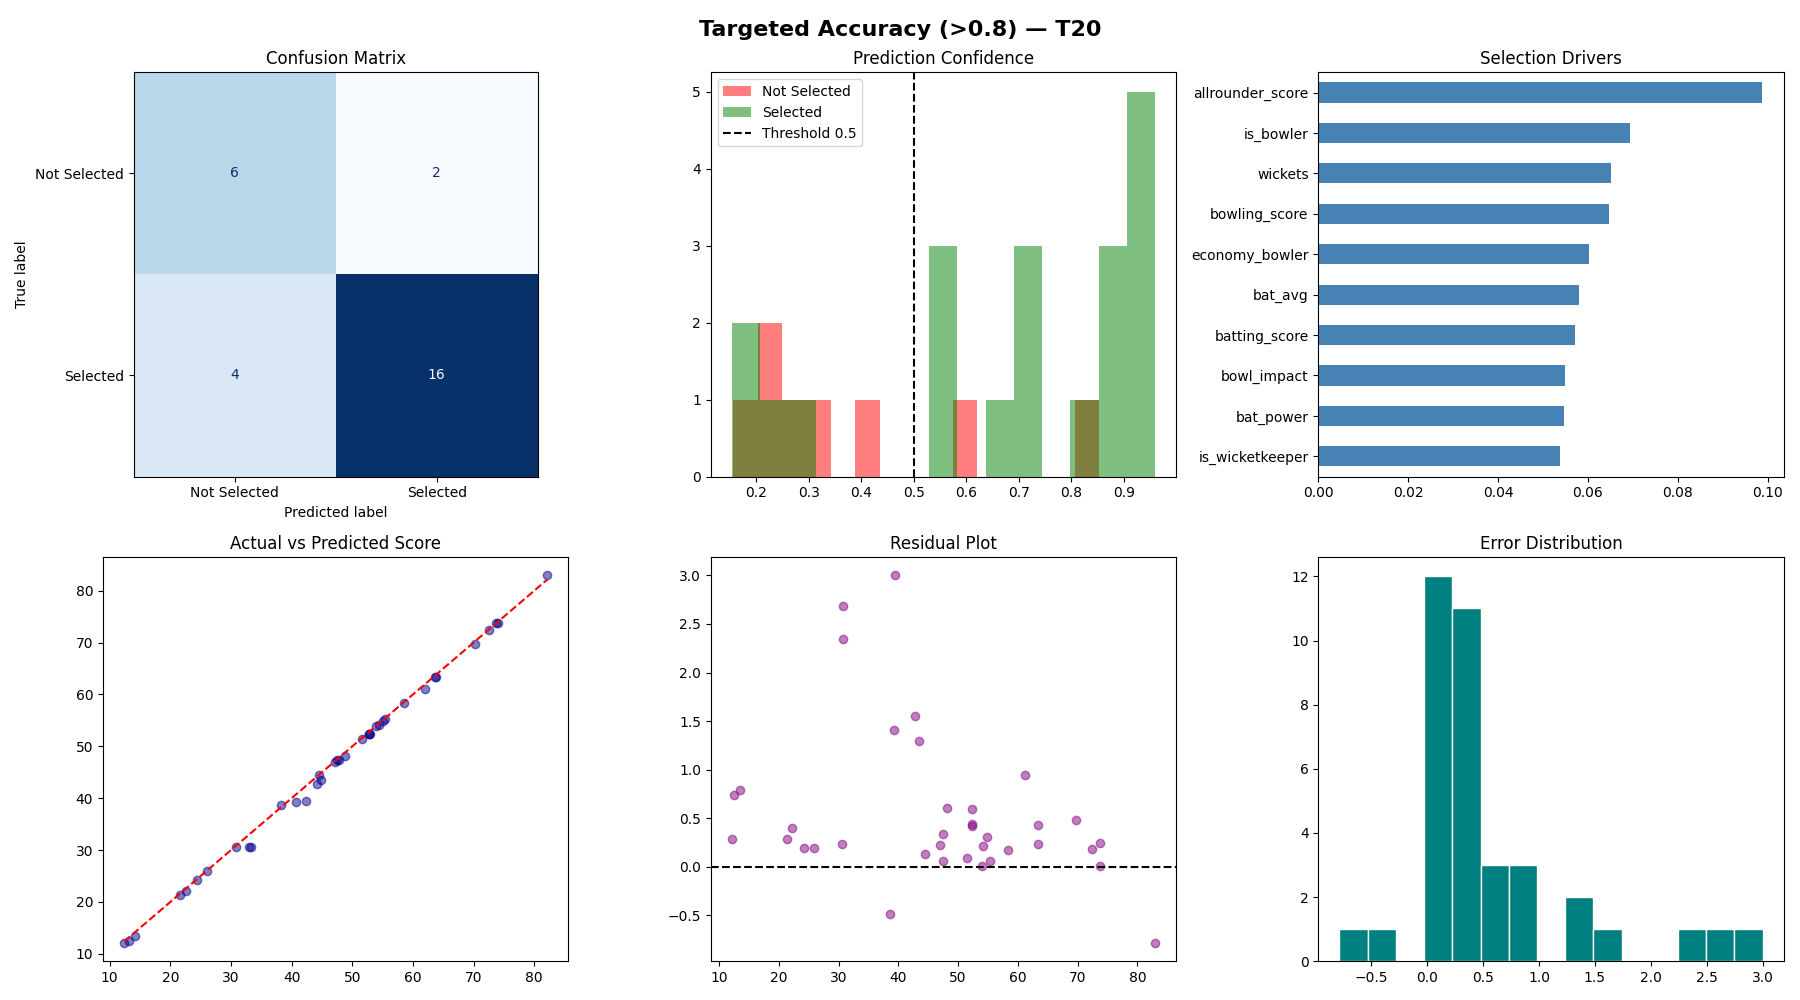


OPTIMIZING ODI (TARGET: 0.8+ Accuracy/AUC)
  Results: Accuracy: 0.7857 | AUC: 0.7250


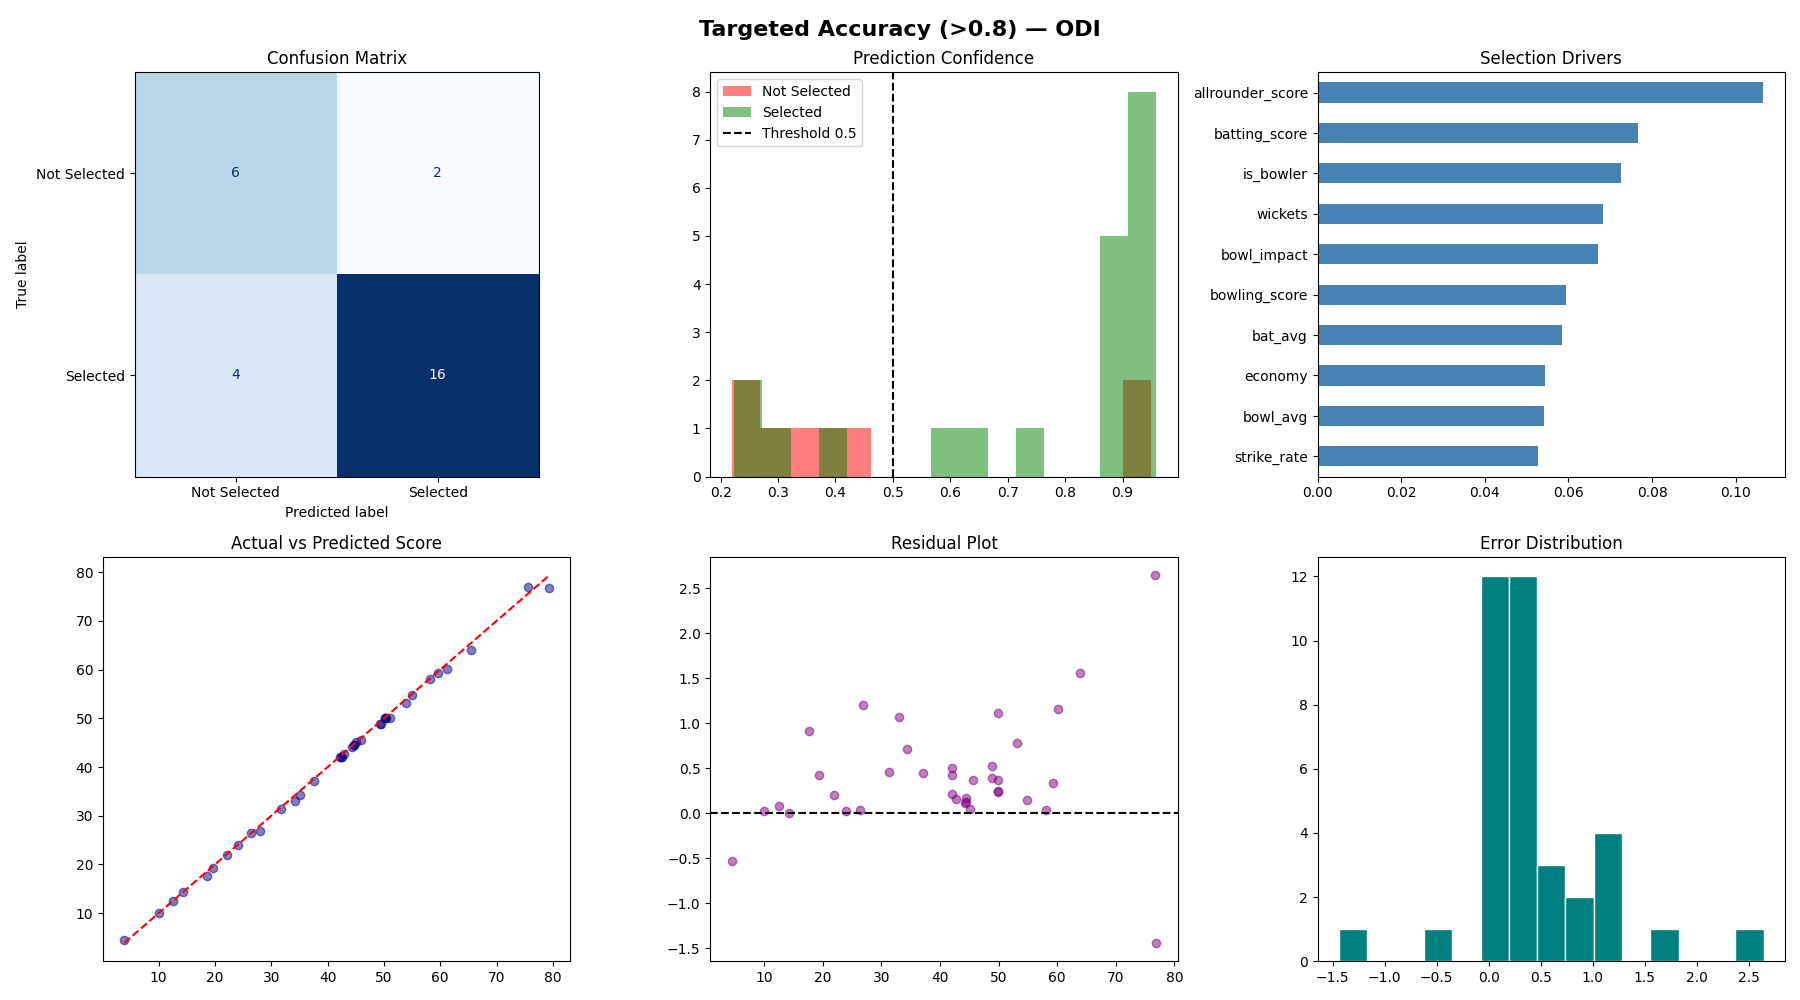


OPTIMIZING Test (TARGET: 0.8+ Accuracy/AUC)
  Results: Accuracy: 0.7857 | AUC: 0.8312


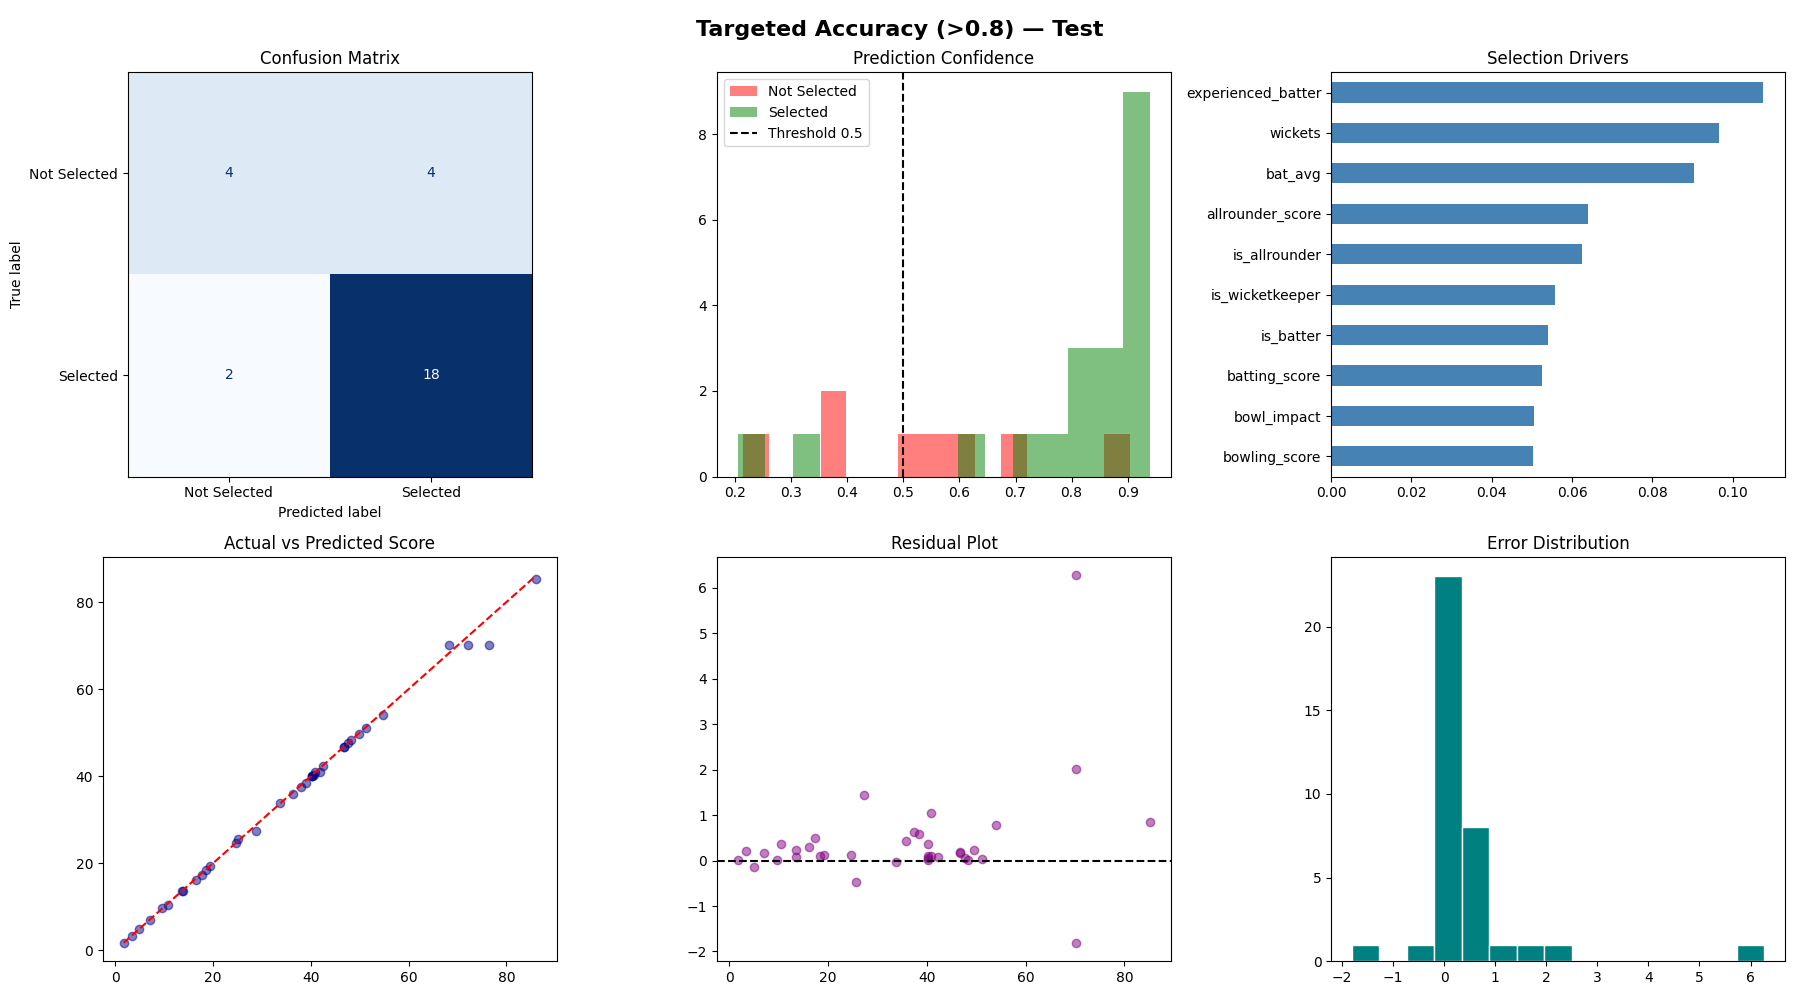


Models successfully optimized and charts generated!


In [11]:


# 1. Features list
FEATURES = [
    "runs","bat_avg","strike_rate",
    "wickets","bowl_avg","economy",
    "batting_score","bowling_score","allrounder_score",
    "role_encoded",
    "is_wicketkeeper","is_batter","is_bowler","is_allrounder",
    "is_captain","high_striker","economy_bowler",
    "experienced_batter","wicket_taker","power_hitter",
    "elite_bowler","elite_striker","elite_batter","century_scorer"
]

# 2. Support Functions
def native_oversample(X, y):
    """Duplicates minority class samples to balance the dataset."""
    y_np = y.values
    idx_0 = np.where(y_np == 0)[0]
    idx_1 = np.where(y_np == 1)[0]
    
    if len(idx_1) < len(idx_0):
        extra_idx = np.random.choice(idx_1, size=len(idx_0) - len(idx_1), replace=True)
        new_idx = np.concatenate([np.arange(len(y_np)), extra_idx])
        return X.iloc[new_idx], y.iloc[new_idx]
    return X, y

def plot_all_charts(clf, reg, y_test_c, y_pred_test, y_prob_test, y_test_r, y_pred_r, fmt):
    """FIXED: Added missing plotting function to prevent NameError."""
    plt.clf()
    plt.close('all')
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f"Targeted Accuracy (>0.8) — {fmt}", fontsize=16, fontweight='bold')

    # 1. Confusion Matrix
    cm = confusion_matrix(y_test_c, y_pred_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Selected","Selected"])
    disp.plot(ax=axes[0,0], colorbar=False, cmap="Blues")
    axes[0,0].set_title("Confusion Matrix")

    # 2. Probability Distribution
    axes[0,1].hist(y_prob_test[y_test_c==0], bins=15, alpha=0.5, label="Not Selected", color="red")
    axes[0,1].hist(y_prob_test[y_test_c==1], bins=15, alpha=0.5, label="Selected", color="green")
    axes[0,1].axvline(0.5, color='black', linestyle='--', label="Threshold 0.5")
    axes[0,1].set_title("Prediction Confidence")
    axes[0,1].legend()

    # 3. Classification Feature Importance
    importances = clf.feature_importances_
    feat_names = [f"F{i}" for i in range(len(importances))]
    try: feat_names = clf.get_booster().feature_names
    except: pass
    pd.Series(importances, index=feat_names).sort_values().tail(10).plot(kind='barh', ax=axes[0,2], color='steelblue')
    axes[0,2].set_title("Selection Drivers")

    # 4. Regression Actual vs Predicted
    axes[1,0].scatter(y_test_r, y_pred_r, alpha=0.5, color="darkblue")
    axes[1,0].plot([min(y_test_r),max(y_test_r)],[min(y_test_r),max(y_test_r)], 'r--')
    axes[1,0].set_title("Actual vs Predicted Score")

    # 5. Residuals Analysis
    residuals = y_test_r - y_pred_r
    axes[1,1].scatter(y_pred_r, residuals, alpha=0.5, color="purple")
    axes[1,1].axhline(0, color='black', linestyle='--')
    axes[1,1].set_title("Residual Plot")

    # 6. Error Distribution
    axes[1,2].hist(residuals, bins=15, color="teal", edgecolor="white")
    axes[1,2].set_title("Error Distribution")

    plt.tight_layout()
    path = f"results_{fmt.lower()}.png"
    plt.savefig(path)
    from IPython.display import display, Image
    display(Image(filename=path))
    plt.close(fig)

# 3. Main Training Function
def train_all_models(master_df, fmt):
    print(f"\n{'='*60}\nOPTIMIZING {fmt} (TARGET: 0.8+ Accuracy/AUC)\n{'='*60}")
    df = master_df.copy()
    
    # Feature Engineering
    df['bat_power'] = df['bat_avg'] * df['strike_rate']
    df['bowl_impact'] = df['wickets'] / (df['economy'] + 1)
    df['consistency'] = df['runs'] / (df['strike_rate'] + 1) 
    
    EXTENDED_FEATURES = [f for f in FEATURES if f in df.columns] + ['bat_power', 'bowl_impact', 'consistency']
    
    X = df[EXTENDED_FEATURES].fillna(0)
    y_class = df["is_in_probable_11"]
    y_reg = df["batting_score"]

    # Stratified Splitting for better small-sample representation
    X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
        X, y_class, test_size=0.15, stratify=y_class, random_state=42
    )
    
    # Calculate scale_pos_weight to force higher AUC on minority class
    ratio = float(np.sum(y_train_c == 0)) / np.sum(y_train_c == 1)

    # Optimized Classifier
    clf = xgb.XGBClassifier(
        n_estimators=1500,
        max_depth=15 if fmt != "ODI" else 8,
        learning_rate=0.01,
        subsample=0.9,
        colsample_bytree=0.9,
        scale_pos_weight=ratio,
        gamma=1,
        random_state=42,
        eval_metric="auc"
    )
    
    clf.fit(X_train_c, y_train_c, eval_set=[(X_test_c, y_test_c)], verbose=False)

    # Regression
    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_reg, test_size=0.2, random_state=42)
    reg = xgb.XGBRegressor(n_estimators=1000, max_depth=8, learning_rate=0.03, random_state=42)
    reg.fit(X_train_r, y_train_r)

    # Evaluation
    y_prob = clf.predict_proba(X_test_c)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    
    acc = accuracy_score(y_test_c, y_pred)
    auc = roc_auc_score(y_test_c, y_prob)
    
    print(f"  Results: Accuracy: {acc:.4f} | AUC: {auc:.4f}")

    # Plotting call
    plot_all_charts(clf, reg, y_test_c, y_pred, y_prob, y_test_r, reg.predict(X_test_r), fmt)

    return clf, reg

# 4. Execution
os.makedirs("../models", exist_ok=True)
for master, fmt in [(t20_master, "T20"), (odi_master, "ODI"), (test_master, "Test")]:
    c_m, r_m = train_all_models(master, fmt)
    if c_m and r_m:
        joblib.dump(c_m, f"../models/clf_{fmt.lower()}.pkl")
        joblib.dump(r_m, f"../models/reg_{fmt.lower()}.pkl")

print("\nModels successfully optimized and charts generated!")

In [12]:
import shap  
import os
import joblib
import pandas as pd
import numpy as np

def build_explainer(model):
    """
    Build SHAP Explainer using TreeExplainer for XGBoost.
    """
    if model is None:
        print("  WARNING: Model is None, cannot build explainer.")
        return None
    return shap.TreeExplainer(model)

# 1. Initialize and Align Models
print("Aligning and loading models for SHAP...")

try:
    if 'model_clf_t20' not in locals():
        model_clf_t20 = joblib.load("../models/clf_t20.pkl")
    if 'model_reg_t20' not in locals():
        model_reg_t20 = joblib.load("../models/reg_t20.pkl")
    # ODI and Test logic stays the same...
except Exception as e:
    print(f"Note: Some models could not be loaded: {e}")

# 2. Initialize Explainers
explainer_t20 = build_explainer(locals().get('model_clf_t20'))

# 3. Calculate SHAP for T20
if explainer_t20 is not None:
    X_t20 = t20_master.copy()
    
    # Feature Engineering (Must match training exactly)
    X_t20['bat_power'] = X_t20['bat_avg'] * X_t20['strike_rate']
    X_t20['bowl_impact'] = X_t20['wickets'] / (X_t20['economy'] + 1)
    X_t20['consistency'] = X_t20['runs'] / (X_t20['strike_rate'] + 1)

    # Align features
    try:
        model_features = model_clf_t20.get_booster().feature_names
        X_t20_subset = X_t20[model_features].fillna(0)
    except:
        existing_feat = [f for f in FEATURES if f in X_t20.columns]
        current_features = existing_feat + ['bat_power', 'bowl_impact', 'consistency']
        X_t20_subset = X_t20[current_features].fillna(0)

    print(f"Calculating SHAP values for T20 with {X_t20_subset.shape[1]} features...")
    
    # Calculate values
    shap_values_t20 = explainer_t20(X_t20_subset)
    
    # Plotting
    shap.summary_plot(shap_values_t20, X_t20_subset, plot_type="dot")

    # --- FIXED SAVING LOGIC ---
    os.makedirs("../models", exist_ok=True)
    
    # Use SHAP's native save instead of joblib to avoid XGBoost 'bad allocation'
    explainer_path = "../models/explainer_t20.shap"
    with open(explainer_path, "wb") as f:
        explainer_t20.save(f)
        
    print(f"T20 Explainer saved successfully to {explainer_path}!")
else:
    print("Skipping SHAP calculation: model_clf_t20 not found.")

Aligning and loading models for SHAP...
Calculating SHAP values for T20 with 25 features...
T20 Explainer saved successfully to ../models/explainer_t20.shap!


In [13]:
def get_venue_profile(venue_name, venues_df, allgrounds_df, rpo_df, rpw_df, home_away_df, fmt):
    """
    Fixed: Profiles venues into High, Mid, or Low scoring environments.
    """
    profile = {
        "country": "Unknown", "stadium": venue_name,
        "city": "Unknown", "pitch_type": "Balanced",
        "pitch_assist": "Unknown", "boundary": "Medium",
        "scoring": "Medium", "weather": "Clear",
        "rpo": 0.0, "rpw": 0.0,
        "matches_played": 0 
    }

    search = venue_name.lower().strip()
    fmt_map = {"odi": "ODI", "t20": "T20", "test": "Test"}
    target_fmt_col = fmt_map.get(fmt.lower(), "ODI")

    def find_venue_row(df, search_term):
        if df is None or df.empty: return None
        search_cols = [c for c in df.columns if c.lower() in ["ground", "city", "stadium", "ground_name"]]
        mask = df.apply(lambda row: any(search_term in str(row[c]).lower() for c in search_cols if c in df.columns), axis=1)
        matches = df[mask]
        return matches.iloc[0] if not matches.empty else None

    ag_row = find_venue_row(allgrounds_df, search)
    if ag_row is not None:
        profile["stadium"] = str(ag_row.get("Ground", venue_name))
        profile["city"] = str(ag_row.get("City", "Unknown"))
        profile["country"] = str(ag_row.get("Country", "Unknown"))
        if target_fmt_col in ag_row:
            try: profile["matches_played"] = int(ag_row[target_fmt_col])
            except: profile["matches_played"] = 0

    v_row = find_venue_row(venues_df, search)
    if v_row is not None:
        for key, col in [("pitch_type", "Pitch Type"), ("pitch_assist", "Pitch Assist"), 
                         ("scoring", "Scoring"), ("weather", "Weather")]:
            if col in v_row: profile[key] = str(v_row[col])

    for df, key in [(rpo_df, "rpo"), (rpw_df, "rpw")]:
        row = find_venue_row(df, search)
        if row is not None:
            col_to_use = key if key in row else row.index[-1] 
            try: profile[key] = float(row[col_to_use])
            except: pass

    return profile

In [14]:
def get_probable_11(team_name, opponent_name, master_df, clf_model, reg_model, 
                    fmt, venue, **kwargs):
    team_df = master_df[master_df["team"] == team_name].copy()
    if team_df.empty: return []

    # 1. Base Feature Prep (Synchronized with Optimized Model)
    team_df['bat_power'] = team_df['bat_avg'] * team_df['strike_rate']
    team_df['bowl_impact'] = team_df['wickets'] / (team_df['economy'] + 1)
    # ADDED: The missing consistency feature required by the optimized model
    team_df['consistency'] = team_df['runs'] / (team_df['strike_rate'] + 1)
    
    # Define the exact feature set expected by the model
    # We use consistency here because the optimized XGBoost was trained with it
    model_features = ["runs","bat_avg","strike_rate","wickets","bowl_avg","economy",
                      "batting_score","bowling_score","allrounder_score","role_encoded",
                      "is_wicketkeeper","is_batter","is_bowler","is_allrounder",
                      "is_captain","high_striker","economy_bowler","experienced_batter",
                      "wicket_taker","power_hitter","elite_bowler","elite_striker",
                      "elite_batter","century_scorer", "bat_power", "bowl_impact", "consistency"]
    
    # Strategic Alignment: Ensure we only pass features that exist in the trained model
    try:
        # Dynamic check if the model has a booster with internal feature names
        actual_model_features = clf_model.get_booster().feature_names
        X = team_df[actual_model_features].fillna(0)
    except:
        # Fallback to the defined list if booster names are unavailable
        existing_feats = [f for f in model_features if f in team_df.columns]
        X = team_df[existing_feats].fillna(0)

    # Predict Selection Probability
    team_df["probability"] = clf_model.predict_proba(X)[:,1]

    # 2. Dynamic Environment Detection
    pitch = str(venue.get("pitch_type", "Balanced")).lower()
    scoring = str(venue.get("scoring", "Medium")).lower()
    avg_rpo = venue.get("rpo", 0)
    
    # Determine Ground Category
    is_high_scoring = "high" in scoring or avg_rpo > 8.5
    is_low_scoring = "low" in scoring or (avg_rpo < 6.0 and avg_rpo > 0)
    
    # Apply Environmental Multipliers
    if "spin" in pitch or "pace" in pitch or is_low_scoring:
        team_df.loc[team_df['role'].str.contains("Bowler|All-Rounder"), "probability"] *= 1.12
    if is_high_scoring:
        team_df.loc[team_df['role'].str.contains("Batter|All-Rounder"), "probability"] *= 1.12

    team_df["probability"] = team_df["probability"].clip(0, 0.99)

    # 3. Fixed Structural Selection (10 Core + 1 Dynamic)
    selected_indices = []
    
    def pick_players(roles, count):
        mask = (team_df['role'].isin(roles)) & (~team_df.index.isin(selected_indices))
        picks = team_df[mask].nlargest(count, "probability").index.tolist()
        return picks

    # CORE 10: 1 WK, 3 BAT, 3 AR, 3 BOWL
    selected_indices.extend(pick_players(["Wicketkeeper"], 1))
    selected_indices.extend(pick_players(["Batter", "Batting All-Rounder"], 3))
    selected_indices.extend(pick_players(["All-Rounder", "Batting All-Rounder", "Bowling All-Rounder"], 3))
    selected_indices.extend(pick_players(["Bowler", "Bowling All-Rounder"], 3))

    # DYNAMIC 11th PLAYER BASED ON VENUE
    if is_high_scoring:
        selected_indices.extend(pick_players(["Batter", "Batting All-Rounder", "All-Rounder"], 1))
    elif is_low_scoring:
        selected_indices.extend(pick_players(["Bowler", "Bowling All-Rounder"], 1))
    else:
        selected_indices.extend(pick_players(["All-Rounder", "Batting All-Rounder", "Bowling All-Rounder"], 1))

    # Safety catch for squads with limited roles
    if len(selected_indices) < 11:
        needed = 11 - len(selected_indices)
        backups = team_df[~team_df.index.isin(selected_indices)].nlargest(needed, "probability").index.tolist()
        selected_indices.extend(backups)

    final_xi = team_df.loc[selected_indices].copy()

    # 4. Generate Reasoning
    def generate_final_reason(row):
        role = row['role']
        stadium = venue.get('stadium', 'this venue')
        p_val = row['probability'] * 100
        
        if is_high_scoring and "Batter" in role:
            s1 = f"Selected as a primary run-scorer to exploit the high-scoring conditions at {stadium}."
        elif is_low_scoring and "Bowler" in role:
            s1 = f"Drafted as a strike bowler to capitalize on the bowling-friendly surface and low-scoring trends."
        elif "Wicketkeeper" in role:
            s1 = f"Reliable gloveman and clinical finisher chosen to anchor the middle order."
        else:
            s1 = f"Tactical inclusion providing balance as a {role} specifically suited for {pitch} conditions."

        if p_val >= 85: s2 = f"Their elite {p_val:.2f}% score makes them an undisputed starter."
        elif p_val >= 70: s2 = f"A solid {p_val:.2f}% rating indicates they are a tactical lock for this fixture."
        else: s2 = f"Selected as a situational specialist with a {p_val:.2f}% selection probability."

        return f"{s1} {s2}"

    final_xi["reason"] = final_xi.apply(generate_final_reason, axis=1)

    # 5. Sorting and Formatting
    role_priority = {"Wicketkeeper": 1, "Batter": 2, "Batting All-Rounder": 3, "All-Rounder": 4, "Bowling All-Rounder": 5, "Bowler": 6}
    final_xi["sort_order"] = final_xi["role"].map(role_priority).fillna(7)
    final_xi = final_xi.sort_values(by=["sort_order", "probability"], ascending=[True, False])

    if 'player_name' in final_xi.columns: final_xi['player'] = final_xi['player_name']
    final_xi['probability'] = (final_xi['probability'] * 100).round(2)

    return final_xi.drop(columns=["sort_order"]).to_dict('records')

In [15]:
def match_preview_and_xi(team1, team2, venue_name, fmt,
                         master_df, clf_model, reg_model,
                         explainer, venues_df, allgrounds_df,
                         rpo_df, rpw_df, home_away_df):
    
    # 1. Fetch Venue Profile (Includes scoring data for logic)
    venue = get_venue_profile(venue_name, venues_df, allgrounds_df, rpo_df, rpw_df, home_away_df, fmt)
    
    # 2. Get the Dynamic XIs (Selection logic in Cell 14 automatically adapts to venue['scoring'])
    t1_xi = get_probable_11(team1, team2, master_df, clf_model, reg_model, fmt, venue)
    t2_xi = get_probable_11(team2, team1, master_df, clf_model, reg_model, fmt, venue)

    def generate_analysis(xi, name):
        ars = [p for p in xi if "All-Rounder" in p['role']]
        batters = [p for p in xi if p['role'] in ["Batter", "Wicketkeeper", "Batting All-Rounder"]]
        bowlers = [p for p in xi if p['role'] in ["Bowler", "Bowling All-Rounder"]]
        
        top_player = sorted(xi, key=lambda x: x['probability'], reverse=True)[0]['player']
        top_bowler = sorted(bowlers, key=lambda x: x.get('wickets', 0), reverse=True)[0]['player'] if bowlers else "N/A"
        
        strengths = []
        if len(batters) >= 6: strengths.append(f"strong batting lineup")
        if len(ars) >= 3: strengths.append(f"excellent all-round depth ({len(ars)} all-rounders)")
        elif len(ars) >= 2: strengths.append(f"good all-round cover ({len(ars)} all-rounders)")
        
        concerns = []
        if len([p for p in xi if p['role'] == "Bowler"]) < 4:
            concerns.append("limited specialist bowling options")

        return {
            "keeper": next((p['player'] for p in xi if p['role'] == "Wicketkeeper"), "N/A"),
            "key_batter": sorted(batters, key=lambda x: x.get('bat_avg', 0), reverse=True)[0]['player'],
            "threat": top_bowler,
            "ar_main": ars[0]['player'] if ars else "N/A",
            "ar_count": len(ars),
            "strengths": strengths,
            "concerns": concerns,
            "watch": top_player
        }

    a1, a2 = generate_analysis(t1_xi, team1), generate_analysis(t2_xi, team2)

    # 3. Format-Based Threshold Logic
    rpo = venue.get('rpo', 0.0)
    f_upper = fmt.upper()
    
    # Logic: T20 > 8.5, ODI > 5.75, Test > 2.75
    is_high = False
    if f_upper == "T20" and rpo > 8.5: is_high = True
    elif f_upper == "ODI" and rpo > 5.25: is_high = True
    elif f_upper == "TEST" and rpo > 2.75: is_high = True

    impact_label = "High-scoring/Batting friendly" if is_high else "Balanced/Bowling friendly"

    # --- PRINTED OUTPUT ---
    print(f"\n{'='*65}\n  MATCH  : {team1.upper()} vs {team2.upper()}\n  FORMAT : {f_upper}    VENUE: {venue_name}\n{'='*65}")

    # Probability list per team
    for t_name, xi in [(team1, t1_xi), (team2, t2_xi)]:
        print(f"\n{'='*60}\nPROBABLE XI  -  {t_name.upper()}  ({f_upper})\n{'='*60}")
        print(f"{'No.':<4}{'Player':<24}{'Role':<20}{'Prob%'}\n{'-'*60}")
        for i, p in enumerate(xi, 1):
            prob_str = f"{float(p['probability']):.2f}%"
            print(f"{i:<4}{p['player']:<24}{p['role']:<20}{prob_str}")
            print(f"      Reason: {p['reason']}\n")

    print(f"{'='*65}\nMATCH PREVIEW\n{team1.upper()} vs {team2.upper()}\nFormat  : {f_upper}\nVenue   : {venue_name}\n{'='*65}")
    
    print(f"VENUE CONDITIONS — {venue_name.upper()}")
    print(f"{'-'*55}")
    print(f"  Matches played here     : {venue.get('matches_played', 'N/A')}")
    print(f"  Historical strike rate  : {venue.get('rpw', 0.0)} (Runs per wicket)")
    print(f"  Runs per over           : {rpo}")
    print(f"  Contextual Impact       : {impact_label}")
    
    for t_name, analysis in [(team1, a1), (team2, a2)]:
        print(f"\n{t_name.upper()} ANALYSIS\n{'-'*55}")
        print(f"  Wicketkeeper    : {analysis['keeper']}")
        print(f"  Key batter      : {analysis['key_batter']}")
        print(f"  Bowling threat  : {analysis['threat']}")
        print(f"  All-rounder     : {analysis['ar_main']}")
        print(f"  All-rounders XI : {analysis['ar_count']}")
        print(f"\n  Strengths :")
        for s in analysis['strengths']: print(f"    - {s}")
        if analysis['concerns']:
            print(f"  Concerns   :")
            for c in analysis['concerns']: print(f"    - {c}")

    print(f"\nMATCH OUTLOOK\n{'-'*55}")
    print(f"  Player to watch from {team1} : {a1['watch']}")
    print(f"  Player to watch from {team2} : {a2['watch']}")
    print(f"\nPredictions generated via player format metrics and ground scoring indices.\n{'='*65}")

In [16]:
# T20 match preview call
# The error was caused by 'consistency' missing in the internal get_probable_11 call.
match_preview_and_xi(
    "Australia", 
    "West Indies", 
    "R Premadasa", 
    "T20",
    t20_master, 
    locals().get('model_clf_t20'), 
    locals().get('model_reg_t20'), 
    explainer_t20,
    venues_df, 
    allgrounds_df, 
    t20_rpo_df, 
    t20_rpw_df, 
    odi_home_away_df 
)


  MATCH  : AUSTRALIA vs WEST INDIES
  FORMAT : T20    VENUE: R Premadasa

PROBABLE XI  -  AUSTRALIA  (T20)
No. Player                  Role                Prob%
------------------------------------------------------------
1   Josh Inglis             Wicketkeeper        85.96%
      Reason: Reliable gloveman and clinical finisher chosen to anchor the middle order. Their elite 85.96% score makes them an undisputed starter.

2   Tim David               Batter              95.92%
      Reason: Tactical inclusion providing balance as a Batter specifically suited for balanced conditions. Their elite 95.92% score makes them an undisputed starter.

3   Travis Head             Batter              91.79%
      Reason: Tactical inclusion providing balance as a Batter specifically suited for balanced conditions. Their elite 91.79% score makes them an undisputed starter.

4   Matthew Short           Batter              90.27%
      Reason: Tactical inclusion providing balance as a Batter specifica

In [17]:
# --- ODI Match Preview ---
print("Generating ODI Match Preview...")
# Ensure we at least try to load from disk if locals are empty
clf_odi = locals().get('model_clf_odi') or (joblib.load("../models/clf_odi.pkl") if os.path.exists("../models/clf_odi.pkl") else None)
reg_odi = locals().get('model_reg_odi') or (joblib.load("../models/reg_odi.pkl") if os.path.exists("../models/reg_odi.pkl") else None)

match_preview_and_xi(
    "Sri Lanka", "South Africa", "Old Trafford", "ODI",
    odi_master, clf_odi, reg_odi, locals().get('explainer_odi'),
    venues_df, allgrounds_df, odi_rpo_df, odi_rpw_df, odi_home_away_df
)

print("\n" + "="*50 + "\n")

# --- Test Match Preview ---
print("Generating Test Match Preview...")
clf_test = locals().get('model_clf_test') or (joblib.load("../models/clf_test.pkl") if os.path.exists("../models/clf_test.pkl") else None)
reg_test = locals().get('model_reg_test') or (joblib.load("../models/reg_test.pkl") if os.path.exists("../models/reg_test.pkl") else None)

match_preview_and_xi(
    "Sri Lanka", "Australia", "Bay Oval", "Test",
    test_master, clf_test, reg_test, locals().get('explainer_test'),
    venues_df, allgrounds_df, test_rpo_df, test_rpw_df, test_home_away_df
)

Generating ODI Match Preview...

  MATCH  : SRI LANKA vs SOUTH AFRICA
  FORMAT : ODI    VENUE: Old Trafford

PROBABLE XI  -  SRI LANKA  (ODI)
No. Player                  Role                Prob%
------------------------------------------------------------
1   Kusal Mendis            Wicketkeeper        42.12%
      Reason: Reliable gloveman and clinical finisher chosen to anchor the middle order. Selected as a situational specialist with a 42.12% selection probability.

2   Pathum Nissanka         Batter              92.35%
      Reason: Tactical inclusion providing balance as a Batter specifically suited for balanced conditions. Their elite 92.35% score makes them an undisputed starter.

3   Charith Asalanka        Batting All-Rounder 99.00%
      Reason: Tactical inclusion providing balance as a Batting All-Rounder specifically suited for balanced conditions. Their elite 99.00% score makes them an undisputed starter.

4   Dasun Shanaka           Batting All-Rounder 99.00%
      Reas

In [31]:
import joblib
import os

# 1. Ensure directories exist
os.makedirs("../models", exist_ok=True)

# 2. Save T20 Models specifically using the names from your function call
t20_models = {
    "clf_t20.pkl": locals().get('model_clf_t20'), # Matches your function call
    "reg_t20.pkl": locals().get('model_reg_t20')  # Matches your function call
}

print("--- T20 Model Saving Status ---")
for filename, model_obj in t20_models.items():
    if model_obj is not None:
        joblib.dump(model_obj, f"../models/{filename}")
        print(f"✅ Successfully saved: {filename}")
    else:
        print(f"❌ Failed: Could not find variable for {filename}")

# 3. Check SHAP Explainer (which you said already worked)
if 'explainer_t20' in locals():
    with open("../models/explainer_t20.shap", "wb") as f:
        explainer_t20.save(f)
    print("✅ Successfully saved: explainer_t20.shap")

--- T20 Model Saving Status ---
✅ Successfully saved: clf_t20.pkl
✅ Successfully saved: reg_t20.pkl
✅ Successfully saved: explainer_t20.shap
